## PHASE 6 — CARR-LEE VARIANCE SWAP PRICING
**Dataset A — Proxy OpenWeatherMap, Bologna 10 m, 2015–2018 | SMARD Germany 2015–2024**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# ── Named constants ──────────────────────────────────────────────
C0         = 0.13138          # Phase 1 Fourier constant, Dataset A — DO NOT re-estimate
SPLIT_DATE = pd.Timestamp('2018-10-01')  # DE/AT market split
DATE_FMT   = '%b %d, %Y %I:%M %p'
MIN_HOURLY = 20               # Minimum valid hours per day (>= 80% of 24)
ROLL_WIN   = 252
ANN_FACTOR = 252.0

# ── Paths ────────────────────────────────────────────────────────
PHASE3_PATH = '../phase3/'
PHASE4_PATH = '../phase4/'
DATA_PATH   = '../../data/'
FIG_PATH    = '../../benchmark_latex/figures/'

GEN_PATH1  = DATA_PATH + 'Actual_generation_1.csv'
GEN_PATH2  = DATA_PATH + 'Actual_generation_2.csv'
PR_PATH1   = DATA_PATH + 'Day-ahead_prices_1.csv'
PR_PATH2   = DATA_PATH + 'Day-ahead_prices_2.csv'
WIND_PATH  = DATA_PATH + 'data.csv'

# ── SMARD column names ───────────────────────────────────────────
WIND_COL = 'Wind onshore [MWh] Calculated resolutions'
COL_GER  = 'Germany/Luxembourg [\u20ac/MWh] Calculated resolutions'
COL_DE   = 'DE/AT/LU [\u20ac/MWh] Calculated resolutions'

# ── Plot colours ─────────────────────────────────────────────────
DARKBLUE  = '#1a3a5c'
ORANGE    = '#d55e00'
MIDBLUE   = '#4a7ab5'
GREEN     = '#2ca02c'
LIGHTGRAY = '#f5f5f5'

def smard_read(path):
    df = pd.read_csv(path, sep=';', encoding='utf-8-sig',
                     thousands=',', na_values=['-'], low_memory=False)
    df['datetime'] = pd.to_datetime(df['Start date'], format=DATE_FMT)
    return df.set_index('datetime').sort_index()

# ── Load Phase 3 h_series ────────────────────────────────────────
h_series = pd.read_csv(PHASE3_PATH + 'garch_h_series_phase3.csv',
                        index_col=0, parse_dates=True)['h_t']

# ── Load SMARD files ─────────────────────────────────────────────
gen1 = smard_read(GEN_PATH1)
gen2 = smard_read(GEN_PATH2)
pr1  = smard_read(PR_PATH1)
pr2  = smard_read(PR_PATH2)

# ── Load Bologna wind data (hourly) ─────────────────────────────
wind_raw = pd.read_csv(WIND_PATH)
wind_raw.index = pd.to_datetime(wind_raw['date'], utc=True).dt.tz_convert(None)

print('=' * 65)
print('  SECTION 1 -- CONFIGURATION AND DATA LOADING')
print(f'  Dataset A  |  Bologna 10 m  |  C0 = {C0}')
print('=' * 65)
print(f'  Generation file 1 : {len(gen1):,} rows  '
      f'{gen1.index[0].date()} to {gen1.index[-1].date()}')
print(f'  Generation file 2 : {len(gen2):,} rows  '
      f'{gen2.index[0].date()} to {gen2.index[-1].date()}')
print(f'  Prices file 1     : {len(pr1):,} rows  '
      f'{pr1.index[0].date()} to {pr1.index[-1].date()}')
print(f'  Prices file 2     : {len(pr2):,} rows  '
      f'{pr2.index[0].date()} to {pr2.index[-1].date()}')
print(f'  Bologna wind data : {len(wind_raw):,} hourly rows  '
      f'{wind_raw.index[0].date()} to {wind_raw.index[-1].date()}')
print(f'  h_series (Phase 3): {len(h_series)} daily rows  '
      f'{h_series.index[0].date()} to {h_series.index[-1].date()}')
print(f'  C0 (Fourier const) = {C0}  [Dataset A, Phase 1 -- fixed]')

  SECTION 1 -- CONFIGURATION AND DATA LOADING
  Dataset A  |  Bologna 10 m  |  C0 = 0.13138
  Generation file 1 : 52,608 rows  2015-01-01 to 2020-12-31
  Generation file 2 : 35,064 rows  2021-01-01 to 2024-12-31
  Prices file 1     : 26,304 rows  2015-01-01 to 2017-12-31
  Prices file 2     : 61,368 rows  2018-01-01 to 2024-12-31
  Bologna wind data : 35,064 hourly rows  2014-12-31 to 2018-12-31
  h_series (Phase 3): 1462 daily rows  2014-12-31 to 2018-12-31
  C0 (Fourier const) = 0.13138  [Dataset A, Phase 1 -- fixed]


## 2. SMARD WIND GENERATION — DAILY SERIES

In [2]:
print('=' * 65)
print('  SECTION 2 -- SMARD WIND GENERATION -- DAILY SERIES')
print('=' * 65)

wind_hourly = pd.concat([gen1[[WIND_COL]], gen2[[WIND_COL]]]).sort_index()[WIND_COL]
wind_hourly = wind_hourly[~wind_hourly.index.duplicated(keep='first')]

valid_count_gen = wind_hourly.resample('D').count()
G_daily_raw     = wind_hourly.resample('D').sum()
G_daily         = G_daily_raw.where(valid_count_gen >= MIN_HOURLY, np.nan)
G_daily         = G_daily.replace(0.0, np.nan)   # zero-generation days are implausible
G_daily.name    = 'G_daily_MWh'

print(f'  Hourly series : {len(wind_hourly):,} obs  '
      f'{wind_hourly.index[0].date()} to {wind_hourly.index[-1].date()}')
print(f'  Daily series  : {len(G_daily):,} days  NaN={G_daily.isna().sum()}')
print(f'  Mean G_t      : {G_daily.mean():,.1f} MWh/day')
print(f'  Std  G_t      : {G_daily.std():,.1f} MWh/day')
print(f'  Min / Max G_t : {G_daily.min():,.1f} / {G_daily.max():,.1f} MWh/day')

  SECTION 2 -- SMARD WIND GENERATION -- DAILY SERIES
  Hourly series : 87,662 obs  2015-01-01 to 2024-12-31
  Daily series  : 3,653 days  NaN=0
  Mean G_t      : 255,560.1 MWh/day
  Std  G_t      : 196,107.0 MWh/day
  Min / Max G_t : 7,213.8 / 1,060,473.5 MWh/day


## 3. DAY-AHEAD ELECTRICITY PRICES — DAILY SERIES

  SECTION 3 -- DAY-AHEAD ELECTRICITY PRICES -- DAILY SERIES
  Split date: 2018-10-01  (DE/AT/LU before, Germany/Lux after)
  Daily price: 3,653 days  NaN=4
  Mean P_t   : 71.38 EUR/MWh
  Std  P_t   : 78.05 EUR/MWh
  Min / Max  : -53.87 / 699.44 EUR/MWh


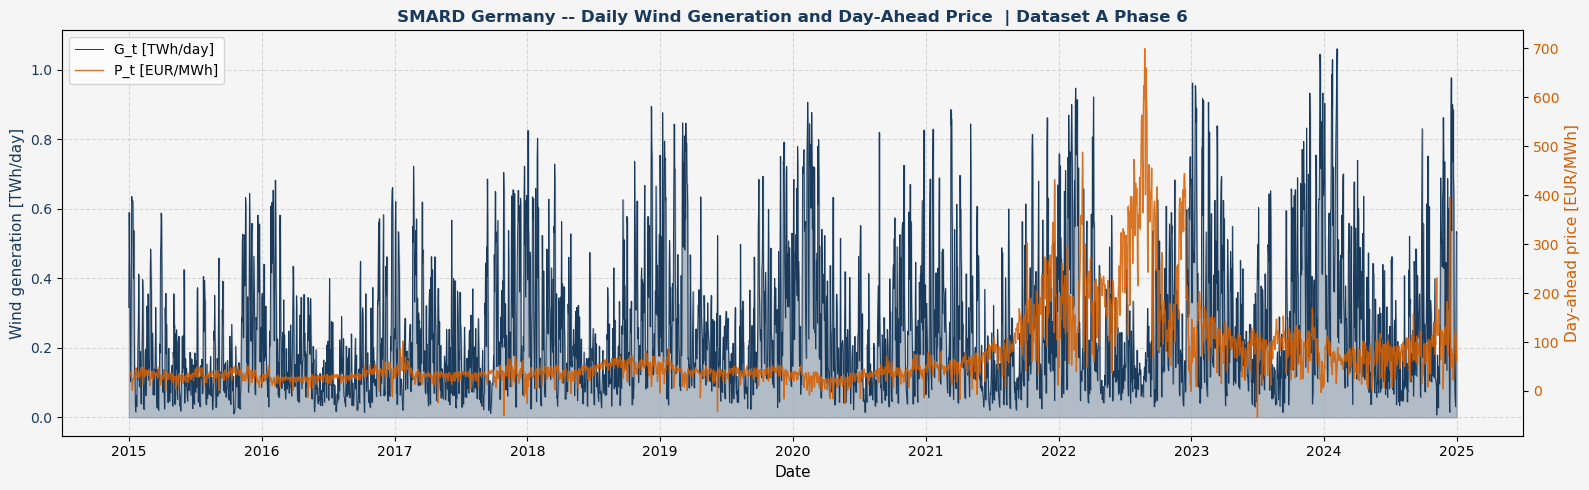

  Figure saved -> phase6_A_smard_overview.png


In [3]:
print('=' * 65)
print('  SECTION 3 -- DAY-AHEAD ELECTRICITY PRICES -- DAILY SERIES')
print('=' * 65)

all_prices   = pd.concat([pr1, pr2]).sort_index()
all_prices   = all_prices[~all_prices.index.duplicated(keep='first')]

# Merge rule: Germany/Luxembourg from 01/10/2018; DE/AT/LU before
price_hourly = all_prices[COL_GER].copy()
mask_pre     = price_hourly.index < SPLIT_DATE
price_hourly.loc[mask_pre] = all_prices.loc[mask_pre, COL_DE]

valid_count_pr = price_hourly.resample('D').count()
P_daily        = price_hourly.resample('D').mean()
P_daily        = P_daily.where(valid_count_pr >= MIN_HOURLY, np.nan)
P_daily.name   = 'price_EUR_MWh'

print(f'  Split date: {SPLIT_DATE.date()}  (DE/AT/LU before, Germany/Lux after)')
print(f'  Daily price: {len(P_daily):,} days  NaN={P_daily.isna().sum()}')
print(f'  Mean P_t   : {P_daily.mean():.2f} EUR/MWh')
print(f'  Std  P_t   : {P_daily.std():.2f} EUR/MWh')
print(f'  Min / Max  : {P_daily.min():.2f} / {P_daily.max():.2f} EUR/MWh')

# Dual-axis overview plot
df_market = pd.DataFrame({'G': G_daily, 'P': P_daily}).dropna(how='all')

fig, ax1 = plt.subplots(figsize=(16, 5))
fig.patch.set_facecolor(LIGHTGRAY); ax1.set_facecolor(LIGHTGRAY)
for sp in ax1.spines.values(): sp.set_color('#cccccc')

ax1.fill_between(df_market.index, df_market['G'] / 1e6, alpha=0.3, color=DARKBLUE)
ax1.plot(df_market.index, df_market['G'] / 1e6, color=DARKBLUE, lw=0.7,
          label='G_t [TWh/day]')
ax1.set_ylabel('Wind generation [TWh/day]', color=DARKBLUE, fontsize=11)
ax1.tick_params(axis='y', labelcolor=DARKBLUE)

ax2 = ax1.twinx()
ax2.plot(df_market.index, df_market['P'], color=ORANGE, lw=1.0, alpha=0.85,
          label='P_t [EUR/MWh]')
ax2.set_ylabel('Day-ahead price [EUR/MWh]', color=ORANGE, fontsize=11)
ax2.tick_params(axis='y', labelcolor=ORANGE)

ax1.set_xlabel('Date', fontsize=11)
ax1.set_title('SMARD Germany -- Daily Wind Generation and Day-Ahead Price  '
               '| Dataset A Phase 6', fontsize=12, color=DARKBLUE, fontweight='bold')
lines1, lbl1 = ax1.get_legend_handles_labels()
lines2, lbl2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, lbl1 + lbl2, fontsize=10, loc='upper left')
ax1.grid(True, ls='--', alpha=0.4, color='#aaaaaa')

plt.tight_layout()
plt.savefig(FIG_PATH + 'phase6_A_smard_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print('  Figure saved -> phase6_A_smard_overview.png')

## 4. LOG-RETURNS AND REALISED VARIANCE (TRACK A)

  SECTION 4 -- LOG-RETURNS AND REALISED VARIANCE (TRACK A)
  Valid log-returns : 3,652
  RV_daily mean     : 0.457984
  RV_daily std      : 0.689470
  K_var^A (rolling 252-day mean, full-sample): 113.998509

  Seasonal annualised RV means:
    DJF: ann RV = 100.7647
    MAM: ann RV = 115.3848
    JJA: ann RV = 119.3166
    SON: ann RV = 126.0107


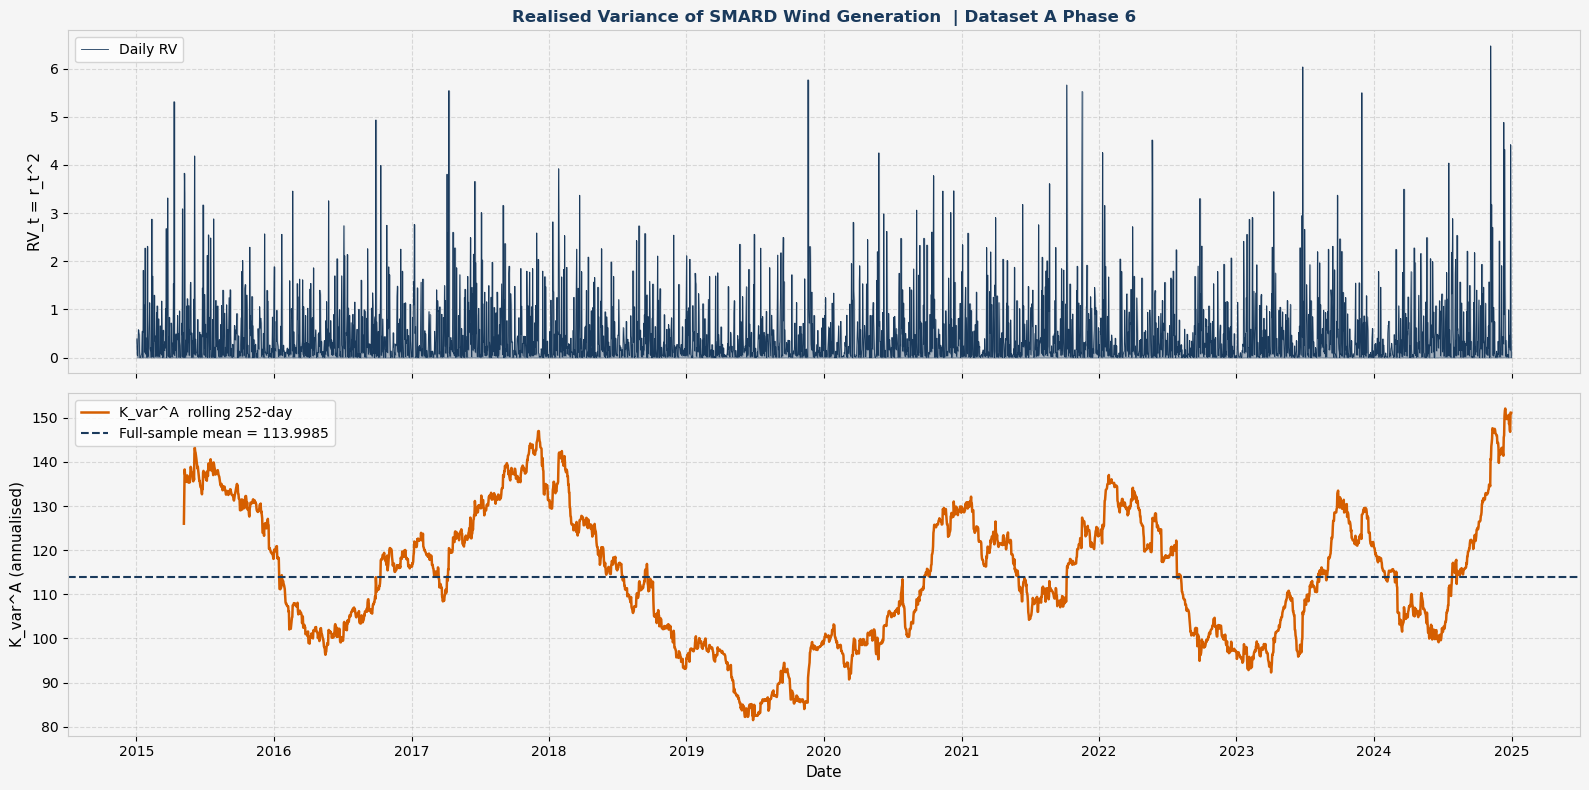

  Figure saved -> phase6_A_rv_tracka.png


In [4]:
print('=' * 65)
print('  SECTION 4 -- LOG-RETURNS AND REALISED VARIANCE (TRACK A)')
print('=' * 65)

G_pos  = G_daily[G_daily > 0].dropna()
r_t    = np.log(G_pos / G_pos.shift(1)).where(G_pos.shift(1) > 0, np.nan)
r_t.name = 'log_return_G'

RV_daily = (r_t ** 2).rename('RV_daily')

K_var_A_series = (ANN_FACTOR * RV_daily.rolling(ROLL_WIN, min_periods=ROLL_WIN // 2)
                  .mean()).rename('K_varA')
K_var_A_scalar = float(K_var_A_series.dropna().mean())

print(f'  Valid log-returns : {r_t.notna().sum():,}')
print(f'  RV_daily mean     : {RV_daily.mean():.6f}')
print(f'  RV_daily std      : {RV_daily.std():.6f}')
print(f'  K_var^A (rolling {ROLL_WIN}-day mean, full-sample): {K_var_A_scalar:.6f}')
print()
seasons = {'DJF': [12,1,2], 'MAM': [3,4,5], 'JJA': [6,7,8], 'SON': [9,10,11]}
print('  Seasonal annualised RV means:')
for s, months in seasons.items():
    rv_s = RV_daily[RV_daily.index.month.isin(months)]
    print(f'    {s}: ann RV = {ANN_FACTOR * rv_s.mean():.4f}')

fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)
fig.patch.set_facecolor(LIGHTGRAY)
for ax in axes:
    ax.set_facecolor(LIGHTGRAY)
    for sp in ax.spines.values(): sp.set_color('#cccccc')

axes[0].fill_between(RV_daily.index, RV_daily.values, alpha=0.35, color=DARKBLUE)
axes[0].plot(RV_daily.index, RV_daily.values, color=DARKBLUE, lw=0.6, label='Daily RV')
axes[0].set_ylabel('RV_t = r_t^2', fontsize=11)
axes[0].set_title('Realised Variance of SMARD Wind Generation  | Dataset A Phase 6',
                   fontsize=12, color=DARKBLUE, fontweight='bold')
axes[0].legend(fontsize=10); axes[0].grid(True, ls='--', alpha=0.4, color='#aaaaaa')

axes[1].plot(K_var_A_series.index, K_var_A_series.values, color=ORANGE, lw=1.8,
              label=f'K_var^A  rolling {ROLL_WIN}-day')
axes[1].axhline(K_var_A_scalar, color=DARKBLUE, lw=1.5, ls='--',
                 label=f'Full-sample mean = {K_var_A_scalar:.4f}')
axes[1].set_ylabel('K_var^A (annualised)', fontsize=11)
axes[1].set_xlabel('Date', fontsize=11)
axes[1].legend(fontsize=10); axes[1].grid(True, ls='--', alpha=0.4, color='#aaaaaa')

plt.tight_layout()
plt.savefig(FIG_PATH + 'phase6_A_rv_tracka.png', dpi=150, bbox_inches='tight')
plt.show()
print('  Figure saved -> phase6_A_rv_tracka.png')

## 5. MODEL-IMPLIED FAIR STRIKE (TRACK B)

In [5]:
print('=' * 65)
print('  SECTION 5 -- MODEL-IMPLIED FAIR STRIKE (TRACK B)')
print('=' * 65)
print()
print('  DEFINITIONS:')
print('  Track A = 252 × rolling-mean(r_t²), SMARD generation log-returns.')
print('  Track B = h × C0, GARCH conditional variance × Fourier integral.')
print('  These measure variance of DIFFERENT processes; unit reconciliation required.')
print()

# ── Static h scenarios ────────────────────────────────────────────────────────
h_t0     = float(h_series.iloc[-1])
h_winter = float(h_series[h_series.index.month.isin([12, 1, 2])].mean())
h_summer = float(h_series[h_series.index.month.isin([6, 7, 8])].mean())
h_base   = 1.0

K_B_ht0   = h_t0     * C0
K_B_hwint = h_winter * C0
K_B_hsum  = h_summer * C0
K_B_h1    = h_base   * C0

print(f'  C0 (Dataset A, Phase 1 constant) = {C0:.6f}')
print(f'  h_t0    = h_series.iloc[-1] = {h_t0:.6f}  (31 Dec 2018)')
print(f'  h_winter (DJF mean)         = {h_winter:.6f}')
print(f'  h_summer (JJA mean)         = {h_summer:.6f}')
print(f'  h_base  (Gaussian)          = {h_base:.6f}')
print()
print(f'  K_var^B(h) = h x C0:')
print(f'    h_t0    -> K_var^B = {K_B_ht0:.6f}')
print(f'    h_winter-> K_var^B = {K_B_hwint:.6f}')
print(f'    h_summer-> K_var^B = {K_B_hsum:.6f}')
print(f'    h=1.0   -> K_var^B = {K_B_h1:.6f}')
print()

# ── Unit reconciliation via delta-method ──────────────────────────────────────
# G = c × W³  =>  Var[log(G_t/G_{t-1})] ≈ (9/W̄²) × Var[W̃]
# => K_var^B_scaled = (9/W_bar²) × h × C0
w_daily_sec5 = wind_raw['wind_speed'].resample('D').mean().dropna()
W_bar = float(w_daily_sec5['2015-01-01':'2018-12-31'].mean())
SCALE_FACTOR = 9.0 / (W_bar ** 2)

K_B_scaled_ht0   = SCALE_FACTOR * K_B_ht0
K_B_scaled_hwint = SCALE_FACTOR * K_B_hwint
K_B_scaled_hsum  = SCALE_FACTOR * K_B_hsum
K_B_scaled_h1    = SCALE_FACTOR * K_B_h1

print(f'  UNIT RECONCILIATION (delta-method, G = c*W^3):')
print(f'  W̄ (Bologna daily mean, 2015-2018) = {W_bar:.4f} m/s')
print(f'  Scale factor = 9 / W̄²            = {SCALE_FACTOR:.6f}')
print(f'  K_var^B_scaled(h) = (9/W̄²) x h x C0:')
print(f'    h_t0    -> K_var^B_scaled = {K_B_scaled_ht0:.6f}')
print(f'    h_winter-> K_var^B_scaled = {K_B_scaled_hwint:.6f}')
print(f'    h_summer-> K_var^B_scaled = {K_B_scaled_hsum:.6f}')
print(f'    h=1.0   -> K_var^B_scaled = {K_B_scaled_h1:.6f}')
print()

# ── Time-varying Track B (rolling) ────────────────────────────────────────────
K_varB_rolling = (h_series * C0).rename('K_varB_rolling')

# Scaled rolling Track B
K_varB_scaled_rolling = (SCALE_FACTOR * K_varB_rolling).rename('K_varB_scaled_rolling')

# Align with rolling Track A for RMSE comparison
df_compare = pd.DataFrame({
    'K_varA':          K_var_A_series,
    'K_varB_scaled':   K_varB_scaled_rolling,
}).dropna()

if len(df_compare) > 0:
    rmse_tracks = float(np.sqrt(((df_compare['K_varA'] - df_compare['K_varB_scaled'])**2).mean()))
else:
    rmse_tracks = np.nan

print(f'  TIME-VARYING Track B: K_varB_rolling_t = h_t x C0')
print(f'  K_varB_rolling range: {K_varB_rolling.min():.6f} to {K_varB_rolling.max():.6f}')
print(f'  K_varB_scaled range : {K_varB_scaled_rolling.min():.6f} to {K_varB_scaled_rolling.max():.6f}')
print(f'  Overlapping obs (rolling A vs B_scaled): {len(df_compare)}')
print(f'  RMSE(K_varA_rolling, K_varB_scaled_rolling) = {rmse_tracks:.6f}')
print(f'  NOTE: large RMSE confirms geographic mismatch -- Bologna units != SMARD units')
print()

# ── Comparison table ──────────────────────────────────────────────────────────
s30, s12 = '-'*30, '-'*12
print(f'  {"Scenario":<30} {"K_varB":>12} {"K_varB_scaled":>14} {"vs K_varA":>12}')
print(f'  {s30} {s12} {"-"*14} {s12}')
print(f'  {"Track A (full-sample mean)":<30} {K_var_A_scalar:>12.6f} {"N/A":>14} {"(benchmark)":>12}')
for label, kv, kvs in [
        ("Track B  h_t0",    K_B_ht0,   K_B_scaled_ht0),
        ("Track B  h_winter", K_B_hwint, K_B_scaled_hwint),
        ("Track B  h_summer", K_B_hsum,  K_B_scaled_hsum),
        ("Track B  h=1.0",   K_B_h1,    K_B_scaled_h1)]:
    ratio = kvs / K_var_A_scalar
    print(f'  {label:<30} {kv:>12.6f} {kvs:>14.6f} {ratio:>11.4f}x')
print()
print(f'  NOTE: C0_A={C0} vs C0_B=1.163. Factor ~{1.163/C0:.0f}x in C0')
print(f'  drives a ~{(0.7511*1.163)/(h_t0*C0):.0f}x gap in K_var^B(h_t0). This is the VoI gap (Phase 7).')

  SECTION 5 -- MODEL-IMPLIED FAIR STRIKE (TRACK B)

  DEFINITIONS:
  Track A = 252 × rolling-mean(r_t²), SMARD generation log-returns.
  Track B = h × C0, GARCH conditional variance × Fourier integral.
  These measure variance of DIFFERENT processes; unit reconciliation required.

  C0 (Dataset A, Phase 1 constant) = 0.131380
  h_t0    = h_series.iloc[-1] = 0.413718  (31 Dec 2018)
  h_winter (DJF mean)         = 0.555916
  h_summer (JJA mean)         = 0.687748
  h_base  (Gaussian)          = 1.000000

  K_var^B(h) = h x C0:
    h_t0    -> K_var^B = 0.054354
    h_winter-> K_var^B = 0.073036
    h_summer-> K_var^B = 0.090356
    h=1.0   -> K_var^B = 0.131380

  UNIT RECONCILIATION (delta-method, G = c*W^3):
  W̄ (Bologna daily mean, 2015-2018) = 2.4690 m/s
  Scale factor = 9 / W̄²            = 1.476402
  K_var^B_scaled(h) = (9/W̄²) x h x C0:
    h_t0    -> K_var^B_scaled = 0.080249
    h_winter-> K_var^B_scaled = 0.107831
    h_summer-> K_var^B_scaled = 0.133402
    h=1.0   -> K_var^B_

## 6. POWER CURVE LINKAGE

  SECTION 6 -- POWER CURVE LINKAGE
  Cross-geographic proxy: Bologna 10 m vs SMARD Germany
  Overlap window : 2015-01-01 to 2018-12-31  (1461 valid paired obs)
  OLS fit: G_t = 36.43 x w^3 + 210,477
  R^2 = 0.0001  (p = 7.2311e-01)
  Expected: weak R^2 -- Bologna 10 m != German hub-height wind
  Interpretation: geographic mismatch motivates Dataset B for pricing.


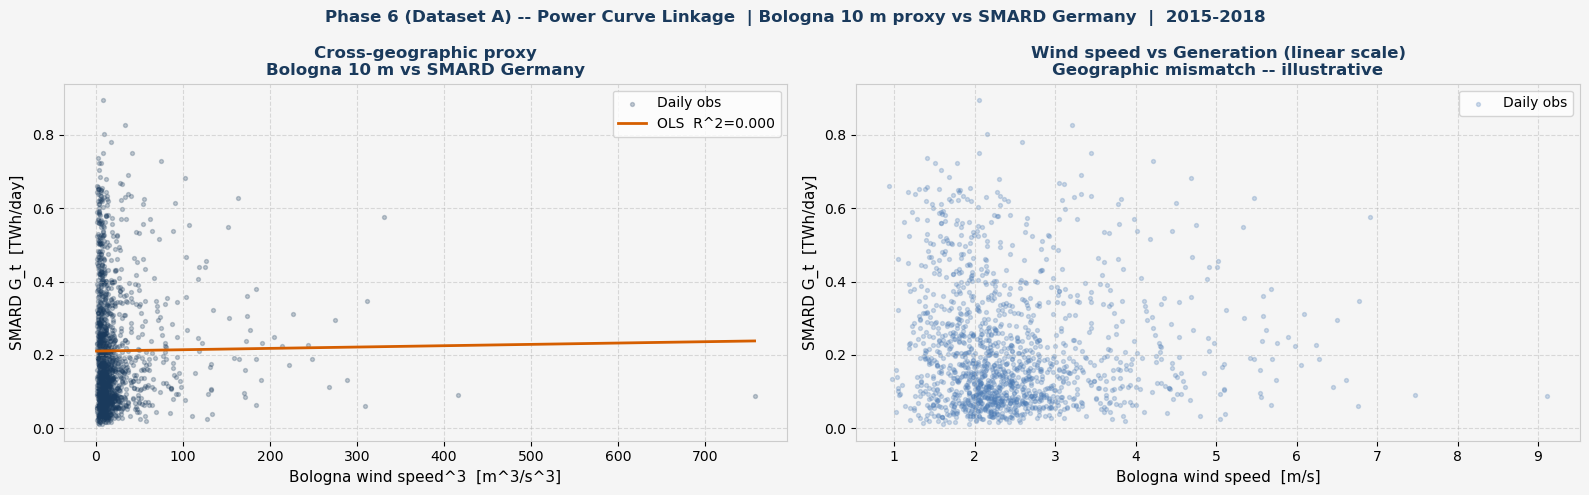

  Figure saved -> phase6_A_power_curve.png


In [6]:
print('=' * 65)
print('  SECTION 6 -- POWER CURVE LINKAGE')
print('  Cross-geographic proxy: Bologna 10 m vs SMARD Germany')
print('=' * 65)

w_daily = wind_raw['wind_speed'].resample('D').mean().rename('wind_speed_ms')

# Restrict to 2015-2018 overlap
w_overlap = w_daily['2015-01-01':'2018-12-31']
G_overlap = G_daily['2015-01-01':'2018-12-31']
df_pc     = pd.DataFrame({'G_MWh': G_overlap, 'w_ms': w_overlap}).dropna()
df_pc['w_cubed'] = df_pc['w_ms'] ** 3

slope, intercept, r_value, p_value, _ = stats.linregress(
    df_pc['w_cubed'], df_pc['G_MWh'])
R2 = r_value ** 2

x_line = np.linspace(df_pc['w_cubed'].min(), df_pc['w_cubed'].max(), 200)
y_line = slope * x_line + intercept

print(f'  Overlap window : 2015-01-01 to 2018-12-31  ({len(df_pc)} valid paired obs)')
print(f'  OLS fit: G_t = {slope:.2f} x w^3 + {intercept:,.0f}')
print(f'  R^2 = {R2:.4f}  (p = {p_value:.4e})')
print(f'  Expected: weak R^2 -- Bologna 10 m != German hub-height wind')
print(f'  Interpretation: geographic mismatch motivates Dataset B for pricing.')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.patch.set_facecolor(LIGHTGRAY)
for ax in axes:
    ax.set_facecolor(LIGHTGRAY)
    for sp in ax.spines.values(): sp.set_color('#cccccc')

axes[0].scatter(df_pc['w_cubed'], df_pc['G_MWh'] / 1e6,
                 alpha=0.25, s=8, color=DARKBLUE, label='Daily obs')
axes[0].plot(x_line, y_line / 1e6, color=ORANGE, lw=2,
              label=f'OLS  R^2={R2:.3f}')
axes[0].set_xlabel('Bologna wind speed^3  [m^3/s^3]', fontsize=11)
axes[0].set_ylabel('SMARD G_t  [TWh/day]', fontsize=11)
axes[0].set_title('Cross-geographic proxy\nBologna 10 m vs SMARD Germany',
                   fontsize=12, color=DARKBLUE, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, ls='--', alpha=0.4, color='#aaaaaa')

axes[1].scatter(df_pc['w_ms'], df_pc['G_MWh'] / 1e6,
                 alpha=0.25, s=8, color=MIDBLUE, label='Daily obs')
axes[1].set_xlabel('Bologna wind speed  [m/s]', fontsize=11)
axes[1].set_ylabel('SMARD G_t  [TWh/day]', fontsize=11)
axes[1].set_title('Wind speed vs Generation (linear scale)\n'
                   'Geographic mismatch -- illustrative',
                   fontsize=12, color=DARKBLUE, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, ls='--', alpha=0.4, color='#aaaaaa')

fig.suptitle('Phase 6 (Dataset A) -- Power Curve Linkage  '
              '| Bologna 10 m proxy vs SMARD Germany  |  2015-2018',
              fontsize=12, color=DARKBLUE, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_PATH + 'phase6_A_power_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print('  Figure saved -> phase6_A_power_curve.png')

## 7. MERIT-ORDER EFFECT

  SECTION 7 -- MERIT-ORDER EFFECT
  Full-sample Pearson rho(G, P) = -0.1616
  Sub-period robustness (DE/AT price split 2018-10-01):
    rho pre-split  (2015-09-30) : -0.4759  (n=1365)
    rho post-split (2018-10-01+): -0.2745  (n=2284)
    Difference = 0.2014 >= 0.05 -- note: sub-period divergence; interpret rolling correlation around split with care.
  Expected: negative (high wind -> low price, merit-order displacement)


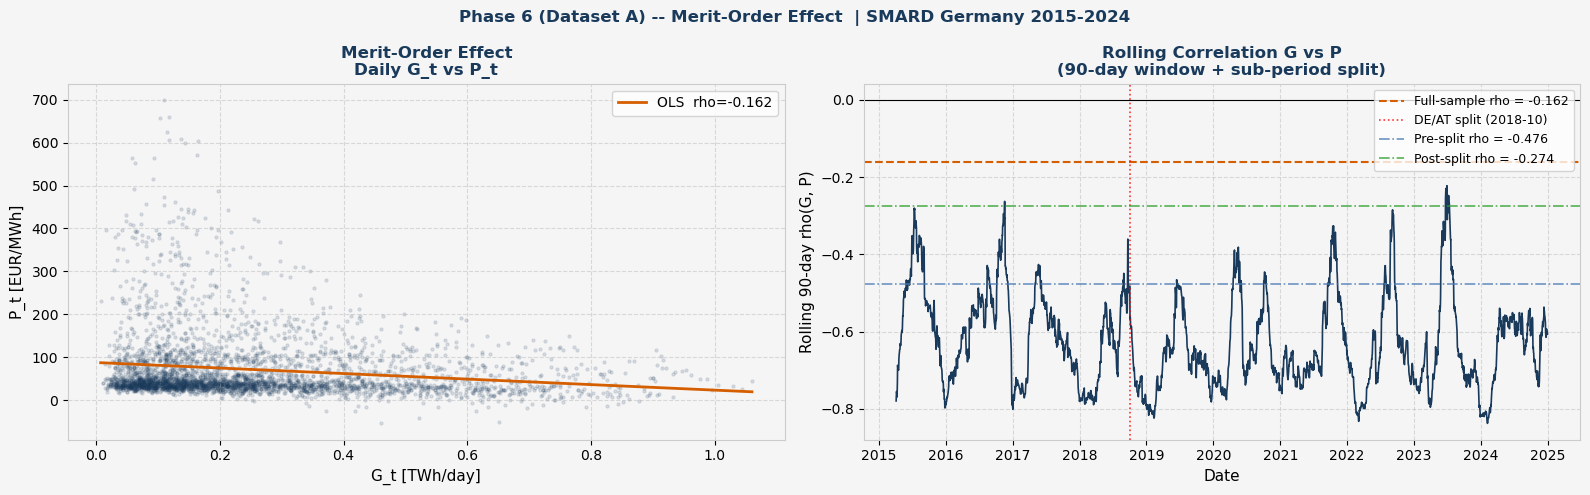

  Figure saved -> phase6_A_merit_order.png


In [7]:
print('=' * 65)
print('  SECTION 7 -- MERIT-ORDER EFFECT')
print('=' * 65)

SPLIT_DATE_MO = pd.Timestamp('2018-10-01')

df_mo    = pd.DataFrame({'G': G_daily, 'P': P_daily}).dropna()
rho_full = df_mo['G'].corr(df_mo['P'])
rho_roll = df_mo['G'].rolling(90).corr(df_mo['P'])

# Sub-period robustness (DE/AT price split 2018-10-01)
df_pre  = df_mo[df_mo.index < SPLIT_DATE_MO]
df_post = df_mo[df_mo.index >= SPLIT_DATE_MO]
rho_pre  = df_pre['G'].corr(df_pre['P'])
rho_post = df_post['G'].corr(df_post['P'])

print(f'  Full-sample Pearson rho(G, P) = {rho_full:.4f}')
print(f'  Sub-period robustness (DE/AT price split 2018-10-01):')
print(f'    rho pre-split  (2015-09-30) : {rho_pre:.4f}  (n={len(df_pre)})')
print(f'    rho post-split (2018-10-01+): {rho_post:.4f}  (n={len(df_post)})')
if abs(rho_pre - rho_post) < 0.05:
    print(f'    Difference = {abs(rho_pre-rho_post):.4f} < 0.05 -- '
          f'structural break has no material effect on merit-order finding.')
else:
    print(f'    Difference = {abs(rho_pre-rho_post):.4f} >= 0.05 -- '
          f'note: sub-period divergence; interpret rolling correlation around split with care.')
print(f'  Expected: negative (high wind -> low price, merit-order displacement)')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.patch.set_facecolor(LIGHTGRAY)
for ax in axes:
    ax.set_facecolor(LIGHTGRAY)
    for sp in ax.spines.values(): sp.set_color('#cccccc')

m, b, r, p, _ = stats.linregress(df_mo['G'] / 1e6, df_mo['P'])
gx = np.linspace(df_mo['G'].min() / 1e6, df_mo['G'].max() / 1e6, 200)
axes[0].scatter(df_mo['G'] / 1e6, df_mo['P'], alpha=0.12, s=5, color=DARKBLUE)
axes[0].plot(gx, m * gx + b, color=ORANGE, lw=2,
             label=f'OLS  rho={rho_full:.3f}')
axes[0].set_xlabel('G_t [TWh/day]', fontsize=11)
axes[0].set_ylabel('P_t [EUR/MWh]', fontsize=11)
axes[0].set_title('Merit-Order Effect\nDaily G_t vs P_t',
                   fontsize=12, color=DARKBLUE, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, ls='--', alpha=0.4, color='#aaaaaa')

axes[1].plot(rho_roll.index, rho_roll.values, color=DARKBLUE, lw=1.2)
axes[1].axhline(rho_full, color=ORANGE, lw=1.5, ls='--',
                label=f'Full-sample rho = {rho_full:.3f}')
axes[1].axvline(SPLIT_DATE_MO, color='red', lw=1.2, ls=':', alpha=0.8,
                label='DE/AT split (2018-10)')
axes[1].axhline(rho_pre,  color=MIDBLUE, lw=1.2, ls='-.', alpha=0.8,
                label=f'Pre-split rho = {rho_pre:.3f}')
axes[1].axhline(rho_post, color=GREEN,   lw=1.2, ls='-.', alpha=0.8,
                label=f'Post-split rho = {rho_post:.3f}')
axes[1].axhline(0, color='black', lw=0.8)
axes[1].set_xlabel('Date', fontsize=11)
axes[1].set_ylabel('Rolling 90-day rho(G, P)', fontsize=11)
axes[1].set_title('Rolling Correlation G vs P\n(90-day window + sub-period split)',
                   fontsize=12, color=DARKBLUE, fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].grid(True, ls='--', alpha=0.4, color='#aaaaaa')

fig.suptitle('Phase 6 (Dataset A) -- Merit-Order Effect  | SMARD Germany 2015-2024',
              fontsize=12, color=DARKBLUE, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_PATH + 'phase6_A_merit_order.png', dpi=150, bbox_inches='tight')
plt.show()
print('  Figure saved -> phase6_A_merit_order.png')

## 8. SYNTHETIC VARIANCE SWAP — PAYOFF SIMULATION

  SECTION 8 -- SYNTHETIC VARIANCE SWAP -- PAYOFF SIMULATION

    Year      N    RV^ann     Pyf_A  Pyf_B_ht0  Pyf_B_hwnt  Pyf_B_hsum  Pyf_B_h1
  ------ ------ --------- --------- ---------- ----------- ----------- ---------
    2015    364  120.8323   +6.8338  +120.7779   +120.7593   +120.7419 +120.7009
    2016    366  113.2301   -0.7684  +113.1758   +113.1571   +113.1398 +113.0987
    2017    365  129.1716  +15.1731  +129.1172   +129.0985   +129.0812 +129.0402
    2018    365  106.1608   -7.8378  +106.1064   +106.0877   +106.0704 +106.0294
    2019    365   95.4870  -18.5115   +95.4326    +95.4139    +95.3966  +95.3556
    2020    366  116.7437   +2.7452  +116.6893   +116.6706   +116.6533 +116.6123
    2021    365  118.9675   +4.9690  +118.9131   +118.8945   +118.8771 +118.8361
    2022    365  101.7962  -12.2023  +101.7418   +101.7231   +101.7058 +101.6648
    2023    365  119.7068   +5.7083  +119.6524   +119.6337   +119.6164 +119.5754
    2024    366  131.9964  +17.9979  +131.9421  

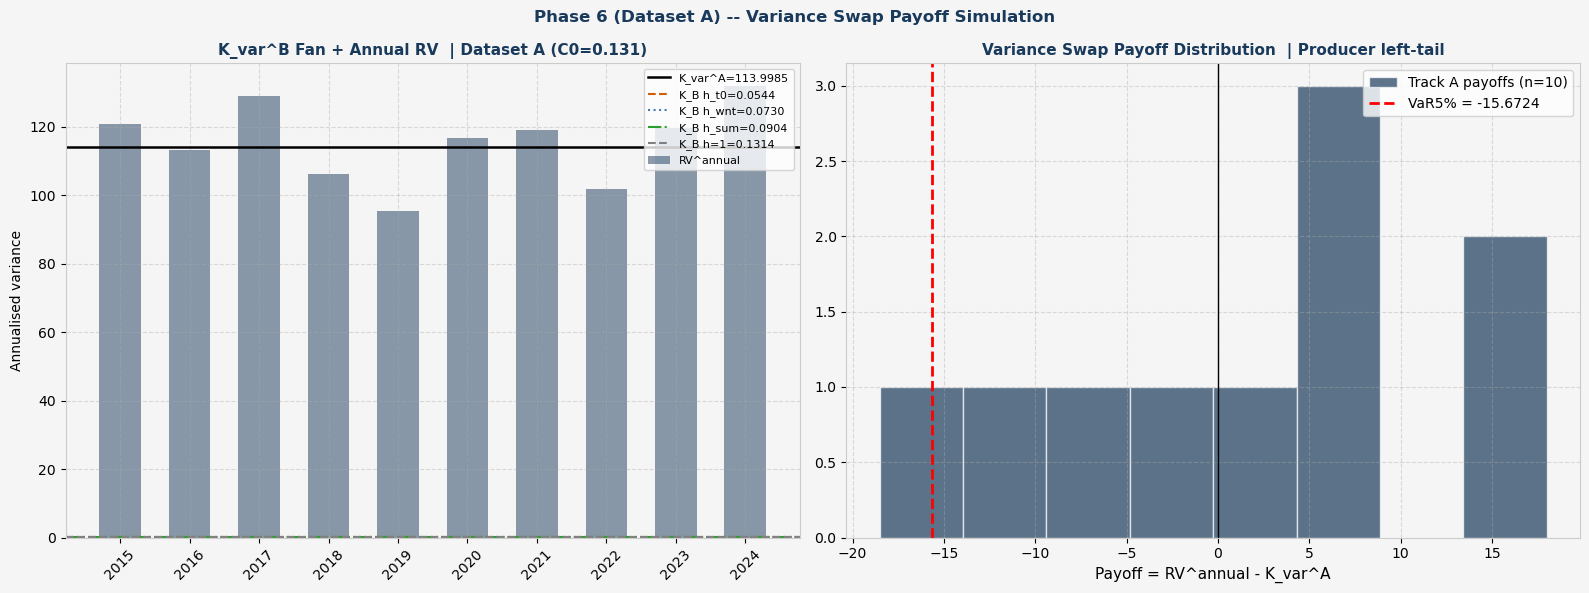

  Figure saved -> phase6_A_payoff_fan.png


In [8]:
print('=' * 65)
print('  SECTION 8 -- SYNTHETIC VARIANCE SWAP -- PAYOFF SIMULATION')
print('=' * 65)
print()

annual_rows = []
for year in range(2015, 2025):
    rv_yr = RV_daily[str(year)].dropna()
    if len(rv_yr) < 100:
        continue
    RV_ann = ANN_FACTOR * rv_yr.mean()
    annual_rows.append({
        'year': year, 'n_days': len(rv_yr), 'RV_annual': RV_ann,
        'Payoff_A':      RV_ann - K_var_A_scalar,
        'Payoff_B_ht0':  RV_ann - K_B_ht0,
        'Payoff_B_hwnt': RV_ann - K_B_hwint,
        'Payoff_B_hsum': RV_ann - K_B_hsum,
        'Payoff_B_h1':   RV_ann - K_B_h1,
    })
payoff_df = pd.DataFrame(annual_rows).set_index('year')

print(f'  {'Year':>6} {'N':>6} {'RV^ann':>9} {'Pyf_A':>9} '
      f'{'Pyf_B_ht0':>10} {'Pyf_B_hwnt':>11} {'Pyf_B_hsum':>11} {'Pyf_B_h1':>9}')
print(f'  {"-"*6} {"-"*6} {"-"*9} {"-"*9} {"-"*10} {"-"*11} {"-"*11} {"-"*9}')
for yr, row in payoff_df.iterrows():
    print(f'  {int(yr):>6} {int(row.n_days):>6} {row.RV_annual:>9.4f} '
          f'{row.Payoff_A:>+9.4f} {row.Payoff_B_ht0:>+10.4f} '
          f'{row.Payoff_B_hwnt:>+11.4f} {row.Payoff_B_hsum:>+11.4f} '
          f'{row.Payoff_B_h1:>+9.4f}')
print()
for col, label in [('Payoff_A', 'Track A'), ('Payoff_B_ht0', 'Track B h_t0'),
                    ('Payoff_B_h1', 'Track B h=1.0')]:
    v = payoff_df[col].dropna()
    print(f'  {label}: mean={v.mean():+.4f}  std={v.std():.4f}  VaR5%={np.percentile(v,5):+.4f}')

# Plot
x     = np.arange(len(payoff_df))
ylbls = payoff_df.index.astype(int)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor(LIGHTGRAY)
for ax in axes:
    ax.set_facecolor(LIGHTGRAY)
    for sp in ax.spines.values(): sp.set_color('#cccccc')

ax0 = axes[0]
ax0.bar(x, payoff_df['RV_annual'].values, color=DARKBLUE, alpha=0.5,
         label='RV^annual', width=0.6)
ax0.axhline(K_var_A_scalar, color='black',  lw=1.8, ls='-',
             label=f'K_var^A={K_var_A_scalar:.4f}')
ax0.axhline(K_B_ht0,  color=ORANGE,  lw=1.5, ls='--', label=f'K_B h_t0={K_B_ht0:.4f}')
ax0.axhline(K_B_hwint,color=MIDBLUE, lw=1.5, ls=':',  label=f'K_B h_wnt={K_B_hwint:.4f}')
ax0.axhline(K_B_hsum, color=GREEN,   lw=1.5, ls='-.', label=f'K_B h_sum={K_B_hsum:.4f}')
ax0.axhline(K_B_h1,   color='grey',  lw=1.5, ls='--', label=f'K_B h=1={K_B_h1:.4f}')
ax0.set_xticks(x); ax0.set_xticklabels(ylbls, rotation=45)
ax0.set_title('K_var^B Fan + Annual RV  | Dataset A (C0=0.131)',
               fontsize=11, color=DARKBLUE, fontweight='bold')
ax0.set_ylabel('Annualised variance')
ax0.legend(fontsize=8, loc='upper right')
ax0.grid(True, ls='--', alpha=0.4, color='#aaaaaa')

ax1 = axes[1]
pyf_a = payoff_df['Payoff_A'].dropna()
var5  = float(np.percentile(pyf_a, 5))
ax1.hist(pyf_a, bins=8, color=DARKBLUE, alpha=0.7, edgecolor='white',
          label=f'Track A payoffs (n={len(pyf_a)})')
ax1.axvline(var5, color='red', lw=2, ls='--', label=f'VaR5% = {var5:+.4f}')
ax1.axvline(0, color='black', lw=1)
ax1.set_xlabel('Payoff = RV^annual - K_var^A', fontsize=11)
ax1.set_title('Variance Swap Payoff Distribution  | Producer left-tail',
               fontsize=11, color=DARKBLUE, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, ls='--', alpha=0.4, color='#aaaaaa')

fig.suptitle('Phase 6 (Dataset A) -- Variance Swap Payoff Simulation',
              fontsize=12, color=DARKBLUE, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_PATH + 'phase6_A_payoff_fan.png', dpi=150, bbox_inches='tight')
plt.show()
print('  Figure saved -> phase6_A_payoff_fan.png')

## 9. COMPLETE SUMMARY TABLE

In [9]:
print('=' * 65)
print('  SECTION 9 -- COMPLETE SUMMARY TABLE')
print('=' * 65)
print()

summary_rows = []
pa = payoff_df['Payoff_A'].dropna()
summary_rows.append({'row': 'Dataset A  Track A', 'K_var': K_var_A_scalar,
                      'payoff_mean': pa.mean(), 'payoff_std': pa.std(),
                      'VaR5pct': np.percentile(pa, 5)})
for label, kv, col in [
        ('Dataset A  Track B  h_t0',     K_B_ht0,   'Payoff_B_ht0'),
        ('Dataset A  Track B  h_winter',  K_B_hwint, 'Payoff_B_hwnt'),
        ('Dataset A  Track B  h_summer',  K_B_hsum,  'Payoff_B_hsum'),
        ('Dataset A  Track B  h=1.0',    K_B_h1,    'Payoff_B_h1')]:
    pv = payoff_df[col].dropna()
    summary_rows.append({'row': label, 'K_var': kv,
                          'payoff_mean': pv.mean(), 'payoff_std': pv.std(),
                          'VaR5pct': np.percentile(pv, 5)})
summary_df = pd.DataFrame(summary_rows).set_index('row')

s40, s12 = '-'*42, '-'*12
print(f'  {"Row":<42} {"K_var":>12} {"Pyf mean":>12} {"Pyf std":>12} {"VaR5%":>12}')
print(f'  {s40} {s12} {s12} {s12} {s12}')
for rl, row in summary_df.iterrows():
    print(f'  {rl:<42} {row.K_var:>12.6f} '
          f'{row.payoff_mean:>+12.6f} {row.payoff_std:>12.6f} '
          f'{row.VaR5pct:>+12.6f}')
print()
print('  Cross-dataset comparison deferred to Phase 7.')
print(f'  Reference Dataset B anchor: C0_B=1.163, h_t0_B~0.751 -> K_var^B_B~0.874')
print(f'  vs Dataset A: K_var^B(h_t0) = {K_B_ht0:.4f}  (factor ~{0.874/K_B_ht0:.0f}x lower)')

  SECTION 9 -- COMPLETE SUMMARY TABLE

  Row                                               K_var     Pyf mean      Pyf std        VaR5%
  ------------------------------------------ ------------ ------------ ------------ ------------
  Dataset A  Track A                           113.998509    +1.410719    11.543892   -15.672395
  Dataset A  Track B  h_t0                       0.054354  +115.354874    11.543892   +98.271759
  Dataset A  Track B  h_winter                   0.073036  +115.336192    11.543892   +98.253077
  Dataset A  Track B  h_summer                   0.090356  +115.318872    11.543892   +98.235757
  Dataset A  Track B  h=1.0                      0.131380  +115.277848    11.543892   +98.194733

  Cross-dataset comparison deferred to Phase 7.
  Reference Dataset B anchor: C0_B=1.163, h_t0_B~0.751 -> K_var^B_B~0.874
  vs Dataset A: K_var^B(h_t0) = 0.0544  (factor ~16x lower)


## 10. SAVE OUTPUTS

In [10]:
print('=' * 65)
print('  SECTION 10 -- SAVE OUTPUTS')
print('=' * 65)

# Master time-series CSV — includes rolling Track B and scaled Track B
df_out = pd.DataFrame({'G_daily_MWh': G_daily, 'price_EUR_MWh': P_daily})
df_out = df_out.join(r_t.rename('log_return_G'), how='left')
df_out = df_out.join(RV_daily.rename('RV_daily'), how='left')
df_out = df_out.join(K_var_A_series.rename('RV_rolling252'), how='left')
df_out['K_varA']            = K_var_A_scalar
df_out['K_varB_ht0']        = K_B_ht0
df_out['K_varB_hwinter']    = K_B_hwint
df_out['K_varB_hsummer']    = K_B_hsum
df_out['K_varB_h1']         = K_B_h1
df_out = df_out.join(K_varB_rolling, how='left')           # time-varying h_t × C0
df_out['K_varB_scaled_ht0'] = K_B_scaled_ht0              # unit-reconciled h_t0 scenario
df_out.index.name = 'date'
df_out.to_csv('variance_swap_phase6.csv')
print(f'  Saved: variance_swap_phase6.csv  ({len(df_out):,} rows, {len(df_out.columns)} cols)')

smard_out = pd.DataFrame({'G_daily_MWh': G_daily, 'price_EUR_MWh': P_daily})
smard_out.index.name = 'date'
smard_out.to_csv('smard_daily_phase6.csv')
print(f'  Saved: smard_daily_phase6.csv    ({len(smard_out):,} rows)')

summary_df.to_csv('variance_swap_summary_phase6.csv')
print(f'  Saved: variance_swap_summary_phase6.csv  ({len(summary_df)} rows)')

print()
print('  -- PHASE 6 (DATASET A) COMPLETE --')
print('=' * 65)
print(f'  K_var^A (full-sample mean)          : {K_var_A_scalar:.6f}')
print(f'  K_var^B (h_t0 = {h_t0:.4f})          : {K_B_ht0:.6f}')
print(f'  K_var^B_scaled (h_t0, delta-method) : {K_B_scaled_ht0:.6f}')
print(f'  RMSE(K_varA_rolling, K_varB_scaled) : {rmse_tracks:.6f}')
print(f'  Power curve R^2 (Bologna 10 m)      : {R2:.4f}  [geographic mismatch]')
print(f'  Merit-order rho(G, P)               : {rho_full:.4f}')
print(f'    pre-split rho  (<2018-10)         : {rho_pre:.4f}')
print(f'    post-split rho (>=2018-10)        : {rho_post:.4f}')
print('  Ready for Phase 7 -- Validation and Value of Information.')

  SECTION 10 -- SAVE OUTPUTS
  Saved: variance_swap_phase6.csv  (3,653 rows, 12 cols)
  Saved: smard_daily_phase6.csv    (3,653 rows)
  Saved: variance_swap_summary_phase6.csv  (5 rows)

  -- PHASE 6 (DATASET A) COMPLETE --
  K_var^A (full-sample mean)          : 113.998509
  K_var^B (h_t0 = 0.4137)          : 0.054354
  K_var^B_scaled (h_t0, delta-method) : 0.080249
  RMSE(K_varA_rolling, K_varB_scaled) : 120.857910
  Power curve R^2 (Bologna 10 m)      : 0.0001  [geographic mismatch]
  Merit-order rho(G, P)               : -0.1616
    pre-split rho  (<2018-10)         : -0.4759
    post-split rho (>=2018-10)        : -0.2745
  Ready for Phase 7 -- Validation and Value of Information.
